11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
>>> Commencing VAE Training...
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.2066
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1471
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1391
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


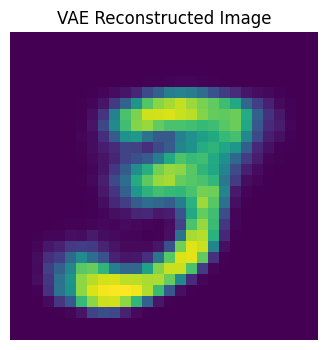

In [1]:
# Roll No: BT23F05F024

import tensorflow as tf
from tensorflow.keras import layers, Model, datasets
import matplotlib.pyplot as plt

# --- 1. Load & Preprocess MNIST Dataset ---
(x_train_raw, _), _ = datasets.mnist.load_data()

# Flatten 28x28 images into 784-dimensional vectors and normalize to [0, 1]
x_train_flat = x_train_raw.reshape(-1, 784).astype("float32") / 255.0

# --- 2. Build the Encoder Architecture ---
input_img = layers.Input(shape=(784,))
encoded_features = layers.Dense(128, activation="relu")(input_img)

# Latent space distribution parameters (Mean and Log-Variance)
z_mu = layers.Dense(8, name="Latent_Mean")(encoded_features)
z_log_var = layers.Dense(8, name="Latent_LogVar")(encoded_features)

# --- 3. Reparameterization Trick ---
def sampling_function(args):
    """Samples z from the parameterized normal distribution."""
    mu, log_var = args
    batch_dim = tf.shape(mu)[0]
    feat_dim = tf.shape(mu)[1]

    # Sample random noise (epsilon)
    epsilon = tf.random.normal(shape=(batch_dim, feat_dim))
    return mu + tf.exp(0.5 * log_var) * epsilon

# Apply the custom sampling function using a Keras Lambda layer
z_sampled = layers.Lambda(sampling_function, name="Latent_Sampling")([z_mu, z_log_var])

# --- 4. Build the Decoder Architecture ---
decoded_features = layers.Dense(128, activation="relu")(z_sampled)
output_img = layers.Dense(784, activation="sigmoid")(decoded_features)

# --- 5. Compile & Train the VAE ---
vae_network = Model(inputs=input_img, outputs=output_img, name="Variational_Autoencoder")
vae_network.compile(optimizer="adam", loss="binary_crossentropy")

print(">>> Commencing VAE Training...")
vae_network.fit(x_train_flat, x_train_flat, epochs=3, batch_size=128, verbose=1)

# --- 6. Prediction & Visualization ---
# Pass the first image through the network to reconstruct it
sample_input = x_train_flat[:1]
reconstructed_output = vae_network.predict(sample_input)

# Plot the reconstructed image
plt.figure(figsize=(4, 4))
plt.imshow(reconstructed_output[0].reshape(28, 28), cmap="viridis")
plt.axis("off")
plt.title("VAE Reconstructed Image")
plt.show()